# 第 9 章 · Skip-gram 代码实验

本页用词向量类比帮助读者理解“向量空间里的语义方向”。重点看最近邻和 king - man + woman 的结果。

[章节网页](../ch9.html)

## 运行内容

- 运行 Word2Vec 类比
- 计算最近邻
- 绘制词向量位置

## 0. 词向量表

这里使用一组可解释的二维/三维向量，目的是看清类比关系，而不是训练大模型。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Word2Vec 经典类比：king - man + woman 应接近 queen。
analogy_words = ["king", "queen", "man", "woman", "prince", "princess", "apple", "orange"]
word_vectors = pd.DataFrame(
    {
        "royalty": [0.92, 0.90, 0.10, 0.10, 0.82, 0.80, 0.05, 0.04],
        "gender": [0.88, -0.88, 0.85, -0.85, 0.72, -0.72, 0.02, -0.02],
        "fruit": [0.02, 0.02, 0.00, 0.00, 0.02, 0.02, 0.92, 0.90],
    },
    index=analogy_words,
)
display(word_vectors)

,royalty,gender,fruit
king,0.92,0.88,0.02
queen,0.90,-0.88,0.02
man,0.10,0.85,0.00
woman,0.10,-0.85,0.00
prince,0.82,0.72,0.02
princess,0.80,-0.72,0.02
apple,0.05,0.02,0.92
orange,0.04,-0.02,0.90


## 1. 类比与最近邻

最近邻展示相似词，类比向量展示方向差。图里的箭头说明 gender 方向如何在词之间迁移。

In [3]:
# 计算最近邻和类比向量。
emb = normalize(word_vectors.to_numpy())
vocab_words = word_vectors.index.to_list()
word_to_id = {word: i for i, word in enumerate(vocab_words)}
sim = cosine_similarity(emb)

analogy_vec = (
    word_vectors.loc["king"].to_numpy()
    - word_vectors.loc["man"].to_numpy()
    + word_vectors.loc["woman"].to_numpy()
)
analogy_vec = normalize(analogy_vec.reshape(1, -1))
analogy_scores = cosine_similarity(analogy_vec, emb)[0]

nearest = pd.DataFrame(
    [
        {"词": word, "最近邻": vocab_words[np.argsort(sim[i])[-2]], "相似度": round(np.sort(sim[i])[-2], 3)}
        for word, i in word_to_id.items()
    ]
)
analogy_df = pd.DataFrame(
    {"候选词": vocab_words, "king - man + woman 相似度": np.round(analogy_scores, 3)}
).sort_values("king - man + woman 相似度", ascending=False)

display(nearest)
display(analogy_df)

,词,最近邻,相似度
0,king,prince,0.999
1,queen,princess,0.999
2,man,king,0.771
3,woman,queen,0.778
4,prince,king,0.999
5,princess,queen,0.999
6,apple,orange,0.999
7,orange,apple,0.999


,候选词,king - man + woman 相似度
5,princess,1.000
1,queen,0.999
3,woman,0.748
4,prince,0.122
0,king,0.080
7,orange,0.064
6,apple,0.042
2,man,-0.574


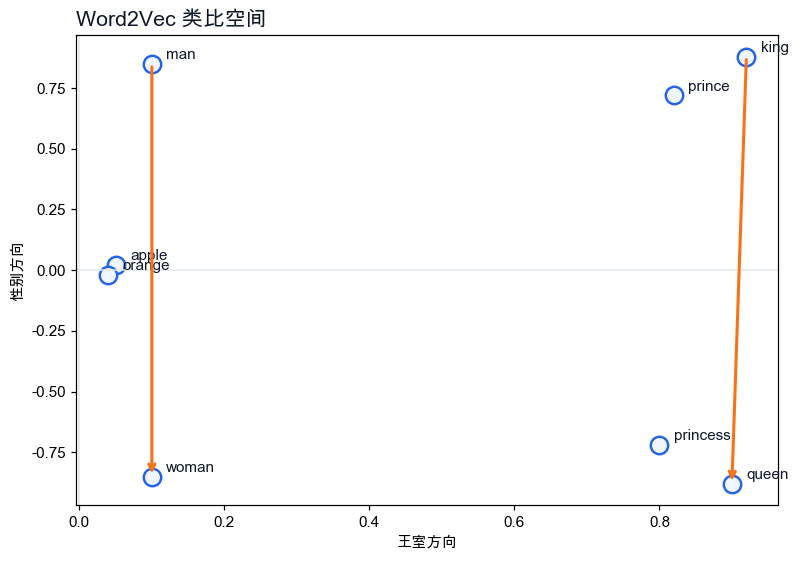

In [4]:
# 绘制词向量位置。
fig, ax = plt.subplots(figsize=(7.4, 5.2))
emb_2d = word_vectors[["royalty", "gender"]].to_numpy()
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=130, color="#eff6ff", edgecolor="#2563eb", linewidth=1.6)
for word, i in word_to_id.items():
    ax.text(emb_2d[i, 0] + 0.02, emb_2d[i, 1] + 0.02, word, color="#0f172a")
ax.annotate("", xy=emb_2d[word_to_id["queen"]], xytext=emb_2d[word_to_id["king"]], arrowprops={"arrowstyle": "->", "color": "#f97316", "lw": 2})
ax.annotate("", xy=emb_2d[word_to_id["woman"]], xytext=emb_2d[word_to_id["man"]], arrowprops={"arrowstyle": "->", "color": "#f97316", "lw": 2})
ax.axhline(0, color="#e2e8f0", linewidth=1)
ax.axvline(0, color="#e2e8f0", linewidth=1)
ax.set_title("Word2Vec 类比空间", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("王室方向")
ax.set_ylabel("性别方向")
plt.tight_layout()
plt.show()